In [1]:
import torch
import torch.multiprocessing as mp
import torchaudio
import numpy as np
from umap import UMAP
import umap.plot
from generics import convert_to_mfcc

/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/U

In [2]:
import pandas as pd
import os

# Loading the dataset
root = "data/cv-corpus-7.0-singleword/en/"
tsv = "train.tsv"
common_voice = torchaudio.datasets.COMMONVOICE(root=root, tsv=tsv)

# Read TSV with pandas for faster indexing
df = pd.read_csv(os.path.join(root, tsv), sep='\t')

# Filter dataset to only include 'yes' and 'no' samples
positive_indices = df[df['sentence'] == 'Firefox'].index.tolist()
negative_indices = df[df['sentence'] == 'no'].index.tolist()

positive_dataset = torch.utils.data.Subset(common_voice, positive_indices)
negative_dataset = torch.utils.data.Subset(common_voice, negative_indices)

positive_loader = torch.utils.data.DataLoader(
    positive_dataset,
    batch_size=1,
    shuffle=True,
)

negative_loader = torch.utils.data.DataLoader(
    negative_dataset,
    batch_size=1,
    shuffle=True,
)


In [3]:
sample = negative_loader.dataset[0]
print(sample)

(tensor([[0.0000e+00, 8.1079e-15, 2.3804e-14,  ..., 1.1286e-04, 2.6515e-04,
         2.6835e-04]]), 48000, {'client_id': '1476c13940c901d1a5a10630c6d84205d0780be5beec08433645f99ecbef03671d2a783194396ecc26df700430fcdbb79fc6eda2cfd7b004305b27a2cc549371', 'path': 'common_voice_en_22107312.mp3', 'sentence': 'no', 'up_votes': '2', 'down_votes': '1', 'age': 'twenties', 'gender': 'male', 'accent': 'indian', 'locale': 'en', 'segment': 'Benchmark'})


In [15]:
# convert Tensor to numpy array for compatibility with other libraries such as umap and scikit-learn
features = []
n_mfcc = 5
# Process a subset of data for demonstration
num_samples = 1000

print("Extracting features...")
for i, (waveform, _, _) in enumerate(positive_loader):
    if i >= num_samples:
        break
        
    mfcc_mean = convert_to_mfcc(waveform=waveform, sample_rate=48000, n_mfcc=n_mfcc)

    features.append(mfcc_mean)
    
for i, (waveform, _, _) in enumerate(negative_loader):
    if i >= num_samples:
        break
        
    mfcc_mean = convert_to_mfcc(waveform=waveform, sample_rate=48000, n_mfcc=n_mfcc)

    features.append(mfcc_mean)

# Stack into a single tensor
features_tensor = torch.cat(features, dim=0)

# Convert to numpy array
features_np = features_tensor.detach().cpu().numpy()

print(f"Converted tensor to numpy array with shape: {features_np.shape}")

Extracting features...
Converted tensor to numpy array with shape: (2000, 15)


## Data Exploration

/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


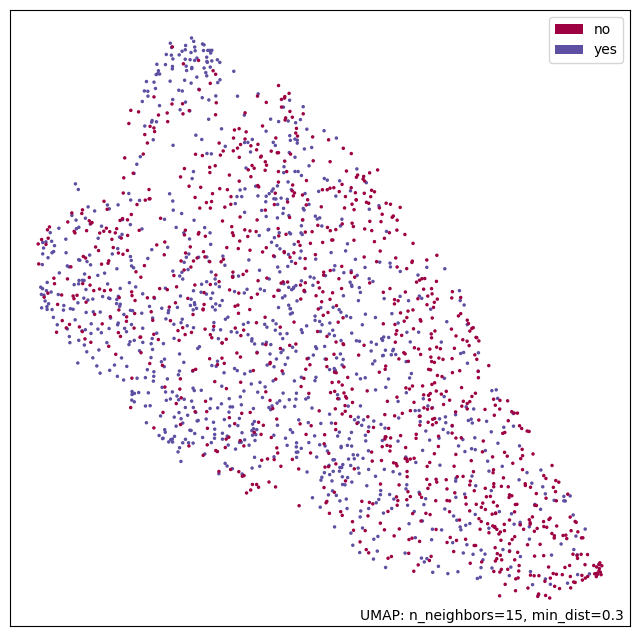

In [7]:
mapper = UMAP(random_state=42, min_dist=0.3, n_neighbors=15).fit(features_np)
# Convert labels to numpy array to avoid 'list object has no attribute shape' error
labels = np.array(['yes'] * num_samples + ['no'] * num_samples)
plotter = umap.plot.points(mapper, labels=labels)

/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nickanthonymiras/miniconda3/envs/audio/lib/python3.10/site-packages/sklear

<Axes: title={'center': 'Colored by RGB coords of Vector Quantization'}>

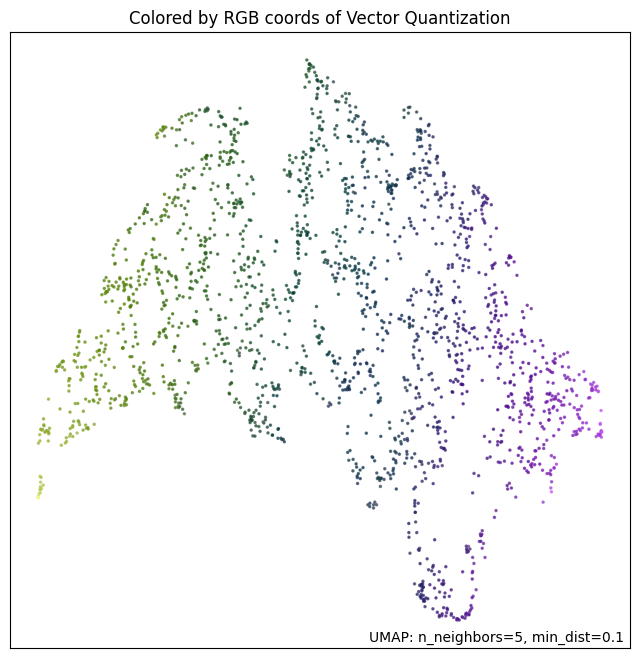

In [6]:
umap.plot.diagnostic(mapper, diagnostic_type='vq')

## Model Training

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_np, labels, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7400

Classification Report:
              precision    recall  f1-score   support

          no       0.72      0.79      0.75       201
         yes       0.76      0.69      0.73       199

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400



# Conclusion